# FAO GAEZ Land Use Maps Generator
Some outputs from the original data are note ok, so these will be replaced using FAO GAEZ data, including:

|Crop|Reason|
|:---|:-----|
|Oil Palm | Land use raster wrong, missing important production zones like Indonesia|
|Tomatoes| SPAM yields overly high, distorting results for some countries |
|Potatoes| Same as tomatoes |
| Maize | Super high yields |
|Tobacco| High yields |

## Suitability Index Inventory
We start by generating a file with all the files we have

In [ ]:
import os
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import rasterio
import importlib
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd

from sbtn_leaf.paths import data_path
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.map_calculations as mc
import sbtn_leaf.cropcalcs as cropcalcs
import sbtn_leaf.RothC_Raster as rothc

Could not determine dtype for column 1, falling back to string


In [2]:
project_root = Path.cwd().parents[1]   # adjust number
soc_raster_folder = project_root/"LEAFs/SOC/rasters_clipped/"
q_breaks = [0,10,30,50,70,90,110,200]

In [3]:
files_folder = "../data/crops/FAO_GAEZ/SuitIndex"
files_prefix = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST."
files_extension = ".tif"
TEC_LOOKUP = {
    "HILM": "high_input_irrigated",
    "HRLM": "high_input_rainfed",
    "LILM": "low_input_irrigated",
    "LRLM": "low_input_rainfed",
}

IRR_LOOKUP = {
    "HILM": "irr",
    "HRLM": "rf",
    "LILM": "irr",
    "LRLM": "rf",
}

In [15]:
crop_index = pl.read_csv(data_path("crops", "FAO_GAEZ", "FAO_GAEZ_croplist.csv")).drop(["description", "index"]).rename({"caption":"crop_name", "code": "crop_code"})

In [16]:
folder_path = data_path("crops", "FAO_GAEZ", "SuitIndex")

In [17]:
output_rows = []

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem
    file_path = str(folder_path / Path(file))
    parts = filename.split(".")
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper()
    tech_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "tech_code": tech_code,
        "technology": TEC_LOOKUP.get(tech_code),
        "irrigation_practice": IRR_LOOKUP.get(tech_code)
    })

df = pl.DataFrame(output_rows)

# Attach crop names
df = df.join(
     other=crop_index,
     on="crop_code",
     how="left"
)

In [18]:
df.head(2)

filename,filepath,crop_code,tech_code,technology,irrigation_practice,crop_name
str,str,str,str,str,str,str
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HILM""","""high_input_irrigated""","""irr""","""Alfalfa"""
"""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""ALF""","""HRLM""","""high_input_rainfed""","""rf""","""Alfalfa"""


Storing it

In [19]:
csv_out_path = project_root / "data" / "crops" / "FAO_GAEZ" / "fao_gaez_crop_suitindex_list.csv"

df.write_csv(
    str(csv_out_path),
    separator=";"
)

In [20]:
fao_gaez_crops = df["crop_name"].unique()

## Attaching to our analyzed crops

In [21]:
sbtn_crops = pl.read_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"))

There a few crop names that need adjustment from FAO GAEZ

In [22]:
CROP_RENAME = {
    "Citrus": "Orange",
    "Sugar cane": "Sugarcane",
    "White potato": "Potato",
}

crop_renaming = pl.DataFrame(
    {"fao_gaez_name": ["Citrus","Sugar cane", "White potato"],
    "sbtn_name": ["Orange", "Sugarcane", "Potato"]}
)

Some don't have matches and are kept the same, including:
- Apples
- Grapes

Updating this couple of names

In [23]:
df = (
    df
    .join(
        crop_renaming,
        left_on="crop_name",
        right_on="fao_gaez_name",
        how="left"
    )
    .with_columns(
        pl.coalesce(["sbtn_name", "crop_name"]).alias("crop_name")
    ).drop("sbtn_name")
)

Now, we need only the high input ones

In [24]:
df = df.filter(pl.col("technology").is_in(["high_input_irrigated","high_input_rainfed"]))

Adding the suitability index file

In [25]:
sbtn_crops = sbtn_crops.join(
    other=df,
    how="left",
    on = ["crop_name", "irrigation_practice"]
)

In [12]:
sbtn_crops.head()

crop_name,crop_practice_string,crop_type,irrigation_practice,filename,filepath,crop_code,tech_code,technology,lu_file,filename_right,filepath_right,crop_code_right,tech_code_right,technology_right
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Barley""","""irr_ron""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""C:\Users\loyola\OneDrive - Wor…","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Barley""","""irr_roff""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated""","""C:\Users\loyola\OneDrive - Wor…","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""HILM""","""high_input_irrigated"""
"""Cabbage""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated""","""C:\Users\loyola\OneDrive - Wor…","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAB""","""HILM""","""high_input_irrigated"""
"""Carrot""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated""","""C:\Users\loyola\OneDrive - Wor…","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""CAR""","""HILM""","""high_input_irrigated"""
"""Cotton""","""irr""","""annual""","""irr""","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated""","""C:\Users\loyola\OneDrive - Wor…","""GAEZ-V5.RES05-SIX.HP0120.AGERA…","""C:\Users\loyola\OneDrive - Wor…","""COT""","""HILM""","""high_input_irrigated"""


Eliminating apple and grapes

In [26]:
sbtn_crops = sbtn_crops.filter(pl.col("tech_code").is_not_null())

Eliminating duplicated _right columns

In [27]:
sbtn_crops = sbtn_crops.select(
    pl.all().exclude("^.*_right$")
)

## Creating land use maps

### LU Generating function

In [28]:
def create_lu_raster(
    input_fao_raster_path: str,
    output_folder: str,
    output_name: None | str = None,
    fao_raster_str_id: str = "GAEZ-V5.RES05-SIX.HP0120.AGERA5.HIST.",
    uhth_path: str = str(data_path("CountryLayers","soc_uht_map.tif")),
    fao_water: int = 9,
    fao_notsuitable: int = 8,
    fao_si_max: int = 7,
    resampling_method: Resampling = Resampling.mode,
):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    # --- open base (target grid) ---
    with rasterio.open(uhth_path) as base:
        base_profile = base.profile.copy()
        base_crs = base.crs
        base_transform = base.transform
        base_shape = (base.height, base.width)
        base_nodata = base.nodata

    # --- open FAO raster (source grid) ---
    with rasterio.open(input_fao_raster_path) as fao:
        fao_crs = fao.crs
        fao_transform = fao.transform
        fao_data = fao.read(1)
        fao_nodata = fao.nodata

    # --- build binary on FAO grid ---
    suitable_mask = (
        (fao_data != fao_nodata)
        & (fao_data != fao_water)
        & (fao_data != fao_notsuitable)
        & (fao_data <= fao_si_max)   # <= is usually what you want
    )

    lu_src = np.where(suitable_mask, 1, 0).astype("uint8")

    # --- reproject/resample onto base grid ---
    lu_dst = np.full(base_shape, 0, dtype="uint8")  # binary output; choose 0 as background

    reproject(
        source=lu_src,
        destination=lu_dst,
        src_transform=fao_transform,
        src_crs=fao_crs,
        src_nodata=0,
        dst_transform=base_transform,
        dst_crs=base_crs,
        dst_nodata=0,
        resampling=resampling_method,
    )

    # --- construct output name ---
    if output_name is None:
        fname = Path(input_fao_raster_path).name
        lu_name = fname.split(fao_raster_str_id, 1)[1].rsplit(".tif", 1)[0]
        output_file = f"{lu_name}.tif"
    else:
        output_file = f"{output_name}.tif"

    output_path = f'{output_folder}/{output_file}'

    # --- update profile for binary output ---
    out_profile = base_profile.copy()
    out_profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw",
    )

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(lu_dst, 1)

    return str(output_path)

### Going through all the files in the excel

In [29]:
output_folder = str(data_path("land_use","FAO_GAEZ"))

In [31]:
output_rows = []

for row in sbtn_crops.iter_rows(named=True):
    input_raster = row["filepath"]
    crop_name = row["crop_name"]
    practice_id = row["crop_practice_string"]

    output_name = f"lu_gaez_{crop_name}_{practice_id}"

    print(f"Creating FAO GAEZ v5 based land use map for {crop_name}_{practice_id}")
    lu_path = create_lu_raster(
        input_fao_raster_path = input_raster,
        output_folder = output_folder,
        output_name = output_name
    )

    #add all info to a df
    output_rows.append(
        {"crop_name": crop_name,
        "crop_practice_string": practice_id,
        "lu_file": lu_path}
    )

df_lu_list = pl.DataFrame(output_rows)

print("\nFinished!")

Creating FAO GAEZ v5 based land use map for Barley_irr_ron
Creating FAO GAEZ v5 based land use map for Barley_irr_roff
Creating FAO GAEZ v5 based land use map for Cabbage_irr
Creating FAO GAEZ v5 based land use map for Carrot_irr
Creating FAO GAEZ v5 based land use map for Cotton_irr
Creating FAO GAEZ v5 based land use map for Maize_irr_ron
Creating FAO GAEZ v5 based land use map for Maize_irr_roff
Creating FAO GAEZ v5 based land use map for Onion_irr
Creating FAO GAEZ v5 based land use map for Potato_irr
Creating FAO GAEZ v5 based land use map for Rapeseed_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_ron
Creating FAO GAEZ v5 based land use map for Sorghum_irr_roff
Creating FAO GAEZ v5 based land use map for Soybean_irr
Creating FAO GAEZ v5 based land use map for Sugar beet_irr
Creating FAO GAEZ v5 based land use map for Sunflower_irr
Creating FAO GAEZ v5 based land use map for Sweet potato_irr
Creating FAO GAEZ v5 based land use map for Tobacco_irr
Creating FAO GAEZ

Checking some outputs

Raster has 1 unique values. Min: 1.00. Max: 1.00


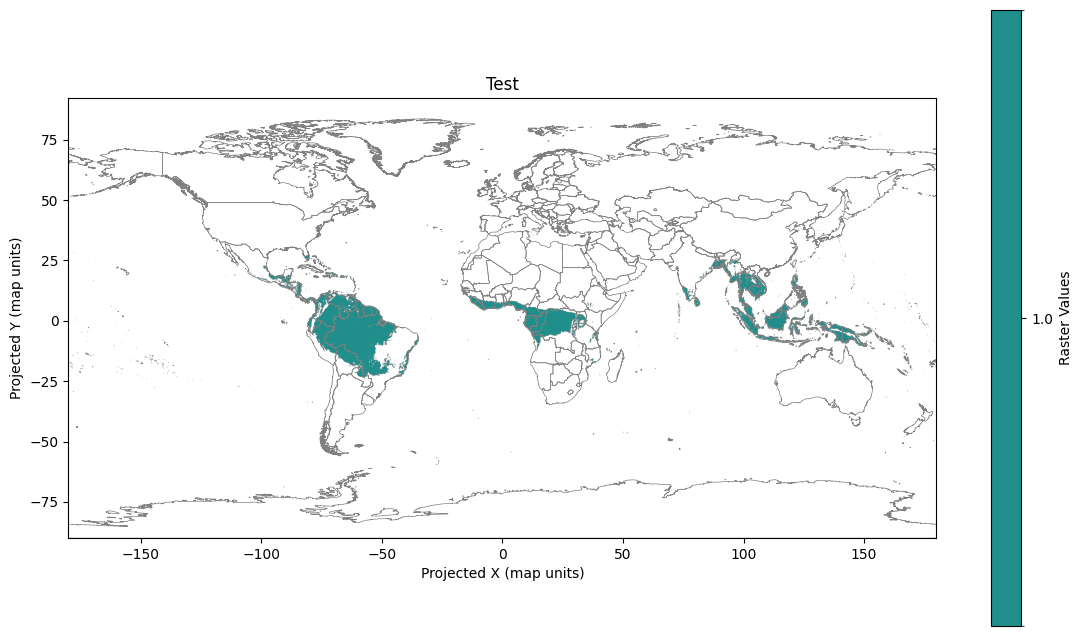

In [32]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Oil palm_rf.tif", "Test")

Raster has 1 unique values. Min: 1.00. Max: 1.00


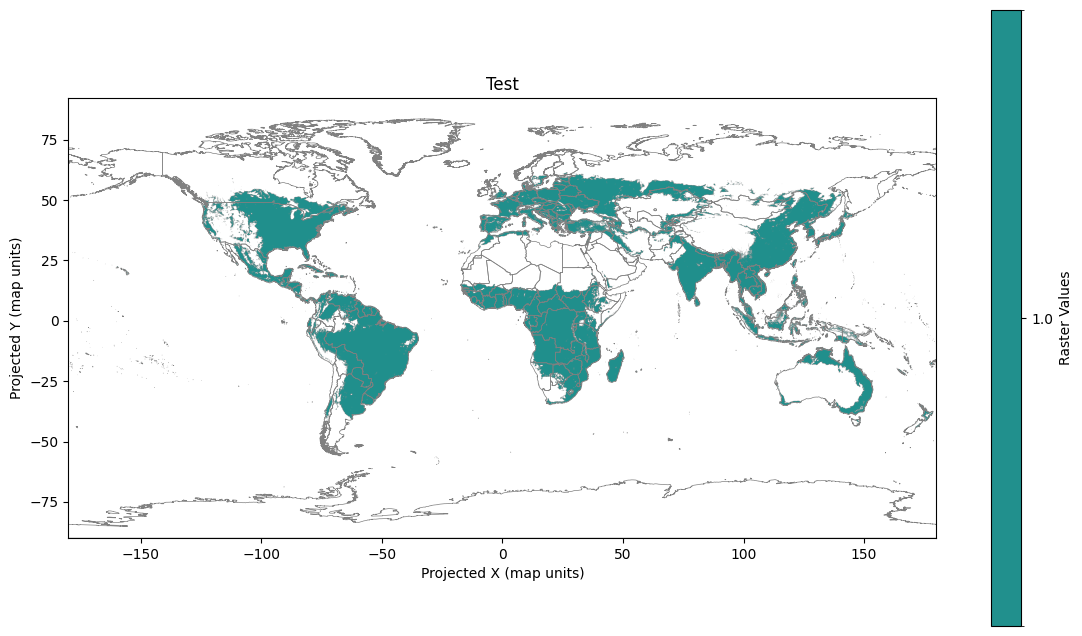

In [24]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Tomato_rf.tif", "Test")

Taking a look at Wheat

Raster has 1 unique values. Min: 1.00. Max: 1.00


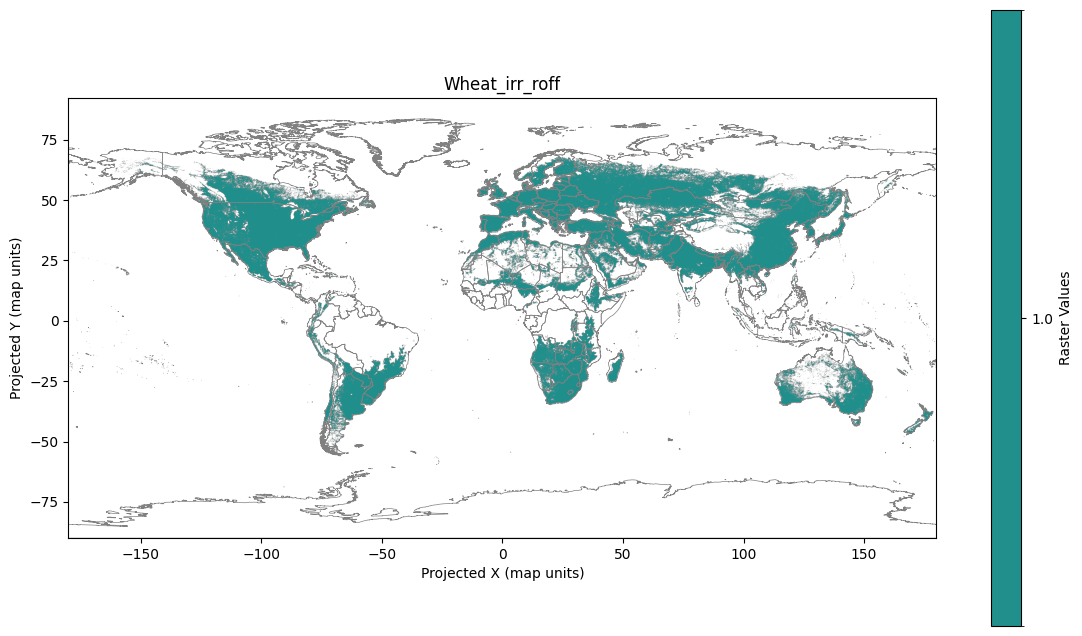

In [35]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Wheat_irr_roff.tif", "Wheat_irr_roff")

Raster has 1 unique values. Min: 1.00. Max: 1.00


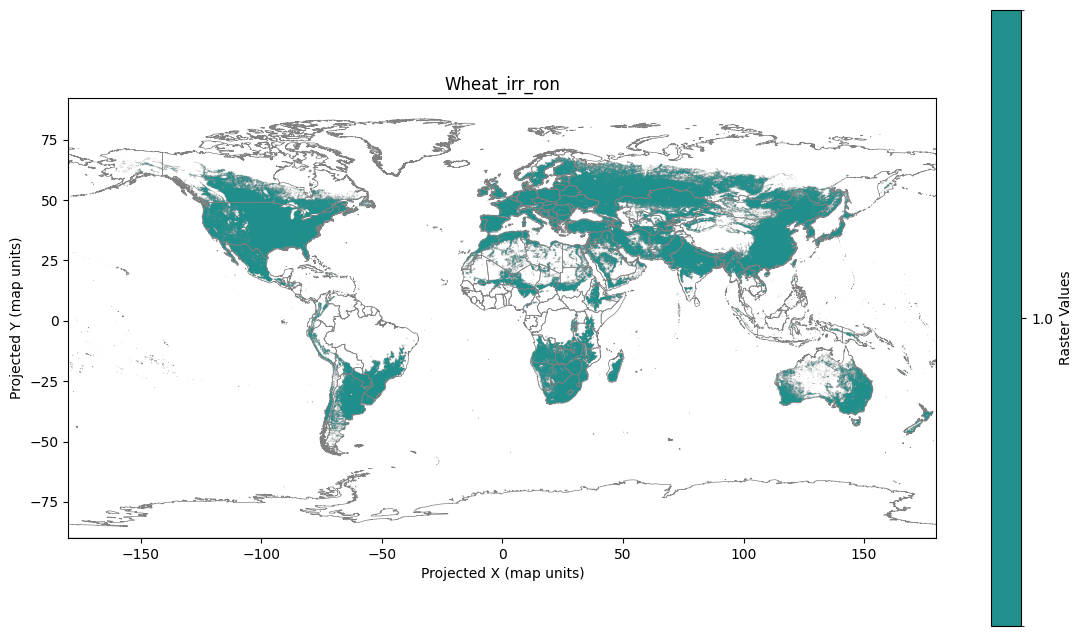

In [36]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Wheat_irr_ron.tif", "Wheat_irr_ron")

Raster has 1 unique values. Min: 1.00. Max: 1.00


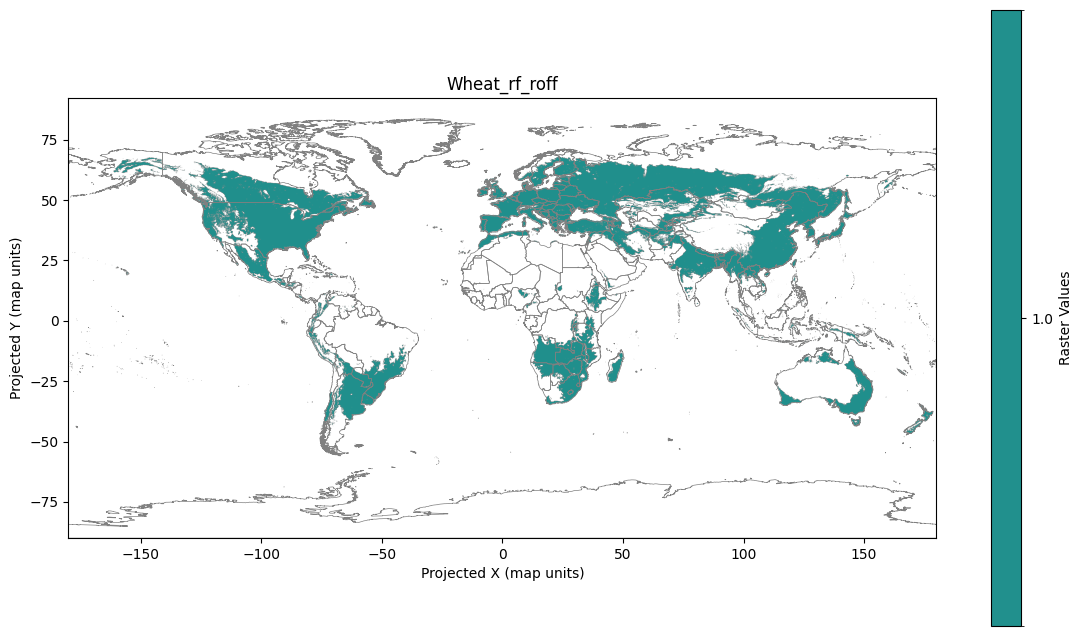

In [37]:
mp.plot_raster_on_world_extremes_cutoff("../../data/land_use/FAO_GAEZ/lu_gaez_Wheat_rf_roff.tif", "Wheat_rf_roff")

They look good.

Adding the output files to the file inventory

In [38]:
df_lu_files = pl.DataFrame(output_rows)

In [39]:
df_lu_files.head(3)

crop_name,crop_practice_string,lu_file
str,str,str
"""Barley""","""irr_ron""","""C:\Users\loyola\OneDrive - Wor…"
"""Barley""","""irr_roff""","""C:\Users\loyola\OneDrive - Wor…"
"""Cabbage""","""irr""","""C:\Users\loyola\OneDrive - Wor…"


Adding it to sbtn_crops

In [40]:
sbtn_crops = sbtn_crops.join(
    other=df_lu_files,
    how="left",
    on = ["crop_name", "crop_practice_string"]
)

Fixing the column names as some crops - irrigation combinations were missing

In [41]:
sbtn_crops = sbtn_crops.drop("lu_file").rename({"lu_file_right":"lu_file"})

Exporting all this info

In [42]:
sbtn_crops.write_excel(data_path("crops","FAO_GAEZ", "crops_file_index.xlsx"), include_header=True)

## Yields FAO GAEZ Inventory

In [43]:
IRR_YLDS_LOOKUP = {
    "WSI": "Irrigated",
    "WSR": "Rainfed",
    "WST": "Total"
}

IRR_CODE_YLDS_LOOKUP = {
    "WSI": "irr",
    "WSR": "rf",
    "WST": "total"
}

In [44]:
ylds_crops_index = pl.read_excel(data_path("crops", "FAO_GAEZ", "YIELDS", "yields_crops_name_index.xlsx")).sort(by = "crop_code")

In [45]:
output_rows = []
folder_path = data_path("crops", "FAO_GAEZ", "YIELDS")

for file in os.listdir(folder_path):
    if not file.lower().endswith(".tif"):  # skip not tif files
        continue

    filename = Path(file).stem  # dropping file extension
    file_path = str(folder_path / Path(file))
    parts = filename.split(".") # splitting based on "."
    if len(parts) < 2:
            continue
    
    crop_code = parts[-2].strip().upper() 
    irr_code = parts[-1].strip().upper()

    output_rows.append({
        "filename": file,
        "filepath": file_path,
        "crop_code": crop_code,
        "irr_code": irr_code,
        "irrigation_practice": IRR_YLDS_LOOKUP.get(irr_code),
        "irrigation_rothc_code": IRR_CODE_YLDS_LOOKUP.get(irr_code),
    })

df_ylds = pl.DataFrame(output_rows)

# Attach crop names
df_ylds = df_ylds.join(
     other=ylds_crops_index,
     on="crop_code",
     how="left"
)

In [46]:
df_ylds.head()

filename,filepath,crop_code,irr_code,irrigation_practice,irrigation_rothc_code,crop_name,index
str,str,str,str,str,str,str,i64
"""GAEZ-V5.RES06-YLD.BAN.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSI""","""Irrigated""","""irr""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WSR""","""Rainfed""","""rf""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BAN.WST.tif""","""C:\Users\loyola\OneDrive - Wor…","""BAN""","""WST""","""Total""","""total""","""Banana and plantain""",1
"""GAEZ-V5.RES06-YLD.BRL.WSI.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSI""","""Irrigated""","""irr""","""Barley""",2
"""GAEZ-V5.RES06-YLD.BRL.WSR.tif""","""C:\Users\loyola\OneDrive - Wor…","""BRL""","""WSR""","""Rainfed""","""rf""","""Barley""",2


Transforming to wide with 3 yields columns

In [47]:
df_ylds_wide = df_ylds.select(["crop_name", "irrigation_practice", "filepath"]).pivot(
    on = "irrigation_practice",
    index = "crop_name",
    values="filepath",
    aggregate_function="first"
)

In [48]:
df_ylds_wide.write_csv(data_path("crops","FAO_GAEZ","YIELDS","faogaez_yield_file_index.csv"), separator=";", include_header=True)

## Updated FAO GAEZ & SPAM RothC Inputs

### Creating the needed data inputs

Loading the inventory data file

In [25]:
annual_crops_prep_files = data_path("crops", "rothc_support","annual_crop_rothc_dataprep_inventory_FAOGAEZ.csv")
perm_crops_prep_files = data_path("crops", "rothc_support","permanent_crop_rothc_dataprep_inventory_FAOGAEZ.csv")

In [28]:
import importlib
importlib.reload(cropcalcs)

Could not determine dtype for column 1, falling back to string


<module 'sbtn_leaf.cropcalcs' from 'C:\\Users\\loyola\\OneDrive - World Wildlife Fund, Inc\\Documents\\203. Python projects\\SBTN_Test\\src\\sbtn_leaf\\cropcalcs.py'>

In [29]:
annuals_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(annual_crops_prep_files)

Creating a unique list of rasters with different land use maps...

  [SKIP] Barley | irr_roff → same LU map as a previously seen scenario (hash b43454db…)
  [SKIP] Maize | irr_roff → same LU map as a previously seen scenario (hash c182636d…)
  [SKIP] Rapeseed | irr_roff → same LU map as a previously seen scenario (hash bd948d33…)
  [SKIP] Sorghum | irr_roff → same LU map as a previously seen scenario (hash caa8e19b…)
  [SKIP] Wheat | irr_roff → same LU map as a previously seen scenario (hash 737f15ed…)
  [SKIP] Barley | rf_roff → same LU map as a previously seen scenario (hash 7cdad76d…)
  [SKIP] Maize | rf_roff → same LU map as a previously seen scenario (hash 5cb1553c…)
  [SKIP] Rapeseed | rf_roff → same LU map as a previously seen scenario (hash 6125aff5…)
  [SKIP] Sugar beet | rf → same LU map as a previously seen scenario (hash 7474df5c…)
  [SKIP] Wheat | rf_roff → same LU map as a previously seen scenario (hash 96a5704b…)
  [SKIP] Sorghum | rf_roff → same LU map as a previously s

In [24]:
perm_unique_data_prepared = cropcalcs.prepare_crop_scenarios_PET_PlantCover_only(perm_crops_prep_files)

Creating a unique list of rasters with different land use maps...

Preparing irrigation and plant cover data for Banana, irr
Creating PET raster...
PET calculation completed for crop 'Banana' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_irr_monthly.tif
Creating plant cover raster...
Plant cover raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\rothc_support\FAO_GAEZ\Banana_irr_pc_monthly.tif
Irrigation, PET, and plant cover rasters created for Banana, irr!!!
Next!

Preparing irrigation and plant cover data for Cocoa, irr
Creating PET raster...
PET calculation completed for crop 'Cocoa' succesfully.
Creating irrigation raster...
Irrigation raster saved to C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\data\crops\

Exporting both these files

In [27]:
annuals_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","annual_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)
perm_unique_data_prepared.to_csv(data_path("crops","rothc_support","FAO_GAEZ","perm_crops_FAO_GAEZ_data_path.csv"), sep=";", index=False)

### Running RothC

#### Annual Crops - Rainfed

In [4]:
annual_crop_rothc_rf_scenarios = "../data/crops/rothc_support/annual_crops_rothc_scenarios_rainfed_FAOGAEZ.xlsx"

In [5]:
rothc.run_rothc_crops_scenarios_from_excel(annual_crop_rothc_rf_scenarios, all_new_files=False, run_test=False, max_workers=4)

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string
Could not determine dtype for column 27, falling back to string
Could not determine dtype for column 28, falling back to string


Annual crop - Barley - rf_ron already exists. Skipping...Annual crop - Barley - rf_roff already exists. Skipping...

Annual crop - Cotton - rf already exists. Skipping...
Annual crop - Groundnut - rf already exists. Skipping...
Running Annual crop - Potato - rf
    Loading environmental data...
Running Annual crop - Maize - rf_ron
    Loading environmental data...
Running Annual crop - Rapeseed - rf_ron
    Loading environmental data...
Running Annual crop - Maize - rf_roff
    Loading environmental data...
    Loading crop data...
    Loading crop data...
    Loading crop data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Potato using 100 stochastic runs
    Running RothC...
        Residues removed. C_inputs are 0's


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Running RothC...
        Calculating baseline residue inputs for annual Maize using 100 stochastic runs
    Running RothC...
        Calculating baseline residue inputs for annual Rapeseed using 100 stochastic runs


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

...

RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sugar beet_rf_2030y_SOC.tif
Annual crop - Sugar beet - rf calculated. Continuing...


Running Annual crop - Tomato - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Tomato using 100 stochastic runs
    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sunflower_rf_2030y_SOC.tif
Annual crop - Sunflower - rf calculated. Continuing...


Annual crop - Wheat - rf_ron already exists. Skipping...
Annual crop - Wheat - rf_roff already exists. Skipping...


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sweet potato_rf_2030y_SOC.tif
Annual crop - Sweet potato - rf calculated. Continuing...


    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Tobacco_rf_2030y_SOC.tif
Annual crop - Tobacco - rf calculated. Continuing...


    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Tomato_rf_2030y_SOC.tif
Annual crop - Tomato - rf calculated. Continuing...




KeyboardInterrupt: 

Checking results...

In [4]:
wheat_rf_roff = project_root / "LEAFs/SOC/rasters_clipped/Wheat_rf_roff_2030y_SOC.tif"
wheat_rf_ron = project_root / "LEAFs/SOC/rasters_clipped/Wheat_rf_ron_2030y_SOC.tif"

In [5]:
mp.inspect_raster(wheat_rf_roff)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Wheat_rf_roff_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Wheat_rf_roff in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.972593784332275
  Max Value: 94.33299255371094
  Mean Value: 54.79049301147461
  Standard Deviation: 18.861860275268555

Band 2:
  Data Type: float32
  Min Value: 6.344897270202637
  Max Value: 94.33299255371094
  Mean Value: 52.08749008178711
  Standard Deviation: 18.928821563720703

Band 3:
  Data Type: floa

In [6]:
mp.inspect_raster(wheat_rf_ron)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Wheat_rf_ron_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Wheat_rf_ron in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.972593784332275
  Max Value: 122.88020324707031
  Mean Value: 55.09003448486328
  Standard Deviation: 19.625146865844727

Band 2:
  Data Type: float32
  Min Value: 7.2230377197265625
  Max Value: 122.88020324707031
  Mean Value: 53.319393157958984
  Standard Deviation: 19.46237564086914

Band 3:
  Data Type: flo

Raster has 774,604 unique values. Min: 7.38. Max: 122.88
Using quantile edges


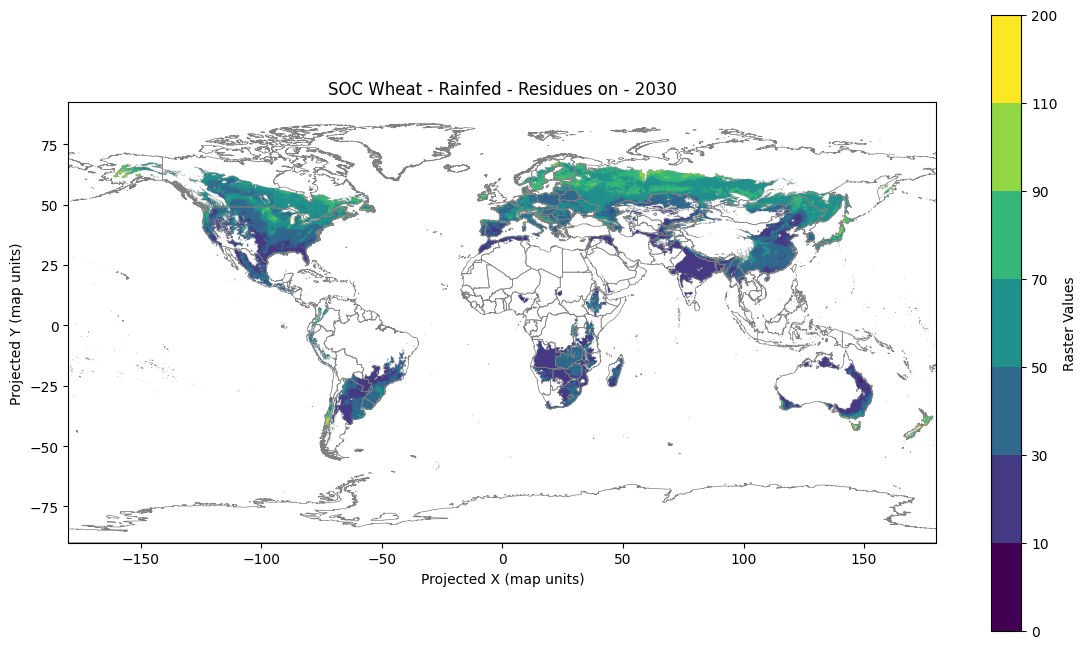

In [7]:
mp.plot_raster_on_world_extremes_cutoff(wheat_rf_ron, "SOC Wheat - Rainfed - Residues on - 2030", perc_cutoff=0, quantiles=q_breaks, raster_band=15)

Raster has 823,007 unique values. Min: 4.11. Max: 94.33
Using quantile edges


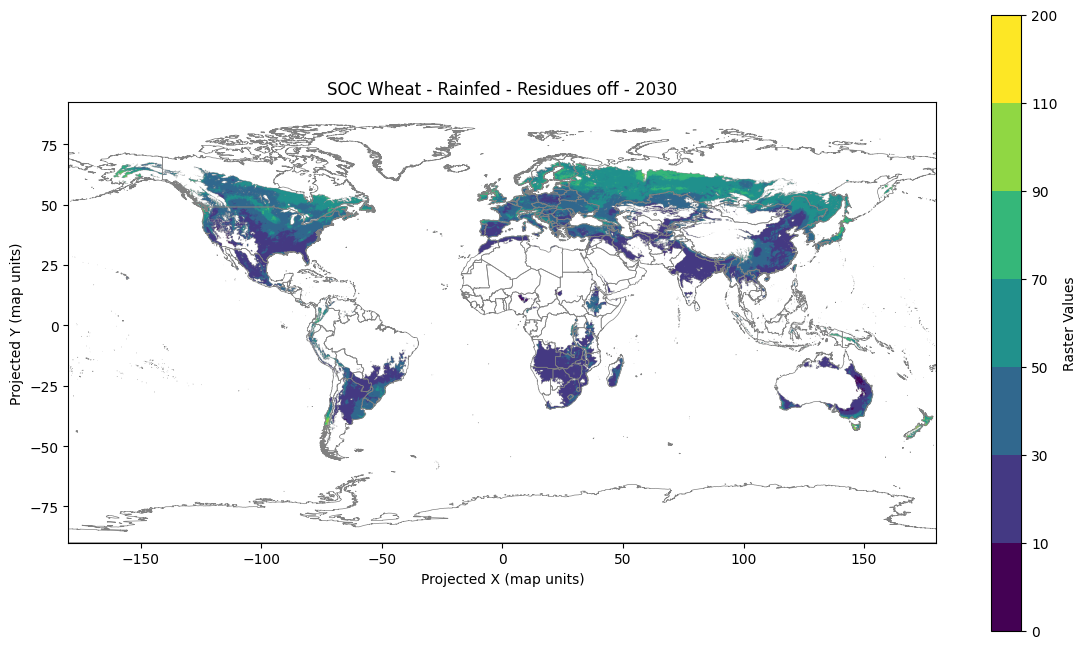

In [9]:
mp.plot_raster_on_world_extremes_cutoff(wheat_rf_roff, "SOC Wheat - Rainfed - Residues off - 2030", perc_cutoff=0, quantiles=q_breaks, raster_band=15)

#### Annual Crops Irrigated

In [7]:
annual_crop_rothc_irr_scenarios = "../data/crops/rothc_support/annual_crops_rothc_scenarios_irrigated_FAOGAEZ.xlsx"

In [8]:
rothc.run_rothc_crops_scenarios_from_excel(annual_crop_rothc_irr_scenarios, all_new_files=False, run_test=False, max_workers=4)

Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string
Could not determine dtype for column 27, falling back to string
Could not determine dtype for column 28, falling back to string


Running Annual crop - Barley - irr_ronRunning Annual crop - Barley - irr_roff
    Loading environmental data...

    Loading environmental data...
Running Annual crop - Cabbage - irr
    Loading environmental data...
Running Annual crop - Carrot - irr
    Loading environmental data...
    Loading crop data...
    Loading crop data...
    Loading crop data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Cabbage using 100 stochastic runs
    Running RothC...
        Calculating baseline residue inputs for annual Barley using 100 stochastic runs
    Running RothC...
        Calculating baseline residue inputs for annual Carrot using 100 stochastic runs
    Running RothC...
        Residues removed. C_inputs are 0's


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

...

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sugar beet_irr_2030y_SOC.tif
Annual crop - Sugar beet - irr calculated. Continuing...


Running Annual crop - Tomato - irr
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Tomato using 100 stochastic runs


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sunflower_irr_2030y_SOC.tif
Annual crop - Sunflower - irr calculated. Continuing...


Annual crop - Wheat - irr_ron already exists. Skipping...
Annual crop - Wheat - irr_roff already exists. Skipping...


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sweet potato_irr_2030y_SOC.tif
Annual crop - Sweet potato - irr calculated. Continuing...


    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Tobacco_irr_2030y_SOC.tif
Annual crop - Tobacco - irr calculated. Continuing...


    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Tomato_irr_2030y_SOC.tif
Annual crop - Tomato - irr calculated. Continuing...




Checking test results

In [12]:
wheat_irr_roff = project_root / "LEAFs/SOC/rasters_clipped/Wheat_irr_roff_2030y_SOC.tif"
wheat_irr_ron = project_root / "LEAFs/SOC/rasters_clipped/Wheat_irr_ron_2030y_SOC.tif"

In [13]:
mp.inspect_raster(wheat_irr_roff)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Wheat_irr_roff_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Wheat_irr_roff in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 89.9429931640625
  Mean Value: 48.112754821777344
  Standard Deviation: 20.815258026123047

Band 2:
  Data Type: float32
  Min Value: 5.632936954498291
  Max Value: 89.9429931640625
  Mean Value: 45.33756637573242
  Standard Deviation: 20.79495620727539

Band 3:
  Data Type: flo

In [14]:
mp.inspect_raster(wheat_irr_ron)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Wheat_irr_ron_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC results for year 2030 for Wheat_irr_ron in ton C/ha
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 6.0228424072265625
  Max Value: 133.57244873046875
  Mean Value: 48.4847412109375
  Standard Deviation: 21.747756958007812

Band 2:
  Data Type: float32
  Min Value: 6.992578983306885
  Max Value: 133.57244873046875
  Mean Value: 47.013553619384766
  Standard Deviation: 21.50035285949707

Band 3:
  Data Type: fl

Raster has 940,233 unique values. Min: 3.33. Max: 89.94
Using quantile edges


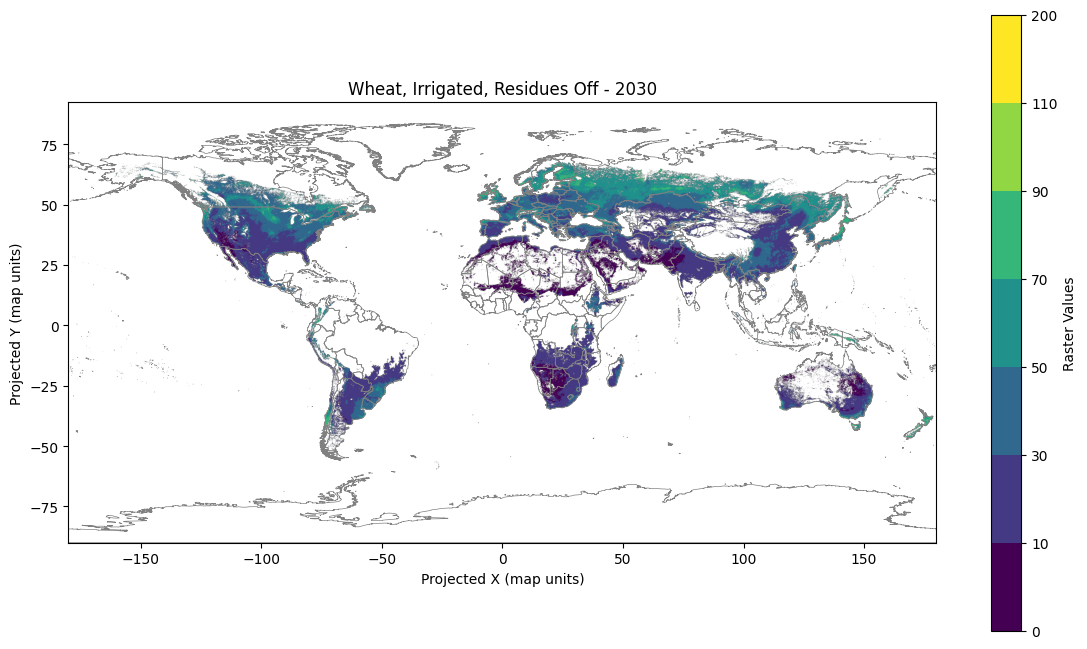

In [15]:
mp.plot_raster_on_world_extremes_cutoff(wheat_irr_roff, "Wheat, Irrigated, Residues Off - 2030", perc_cutoff=0, quantiles = q_breaks, raster_band = 15)

Raster has 882,039 unique values. Min: 6.41. Max: 133.57
Using quantile edges


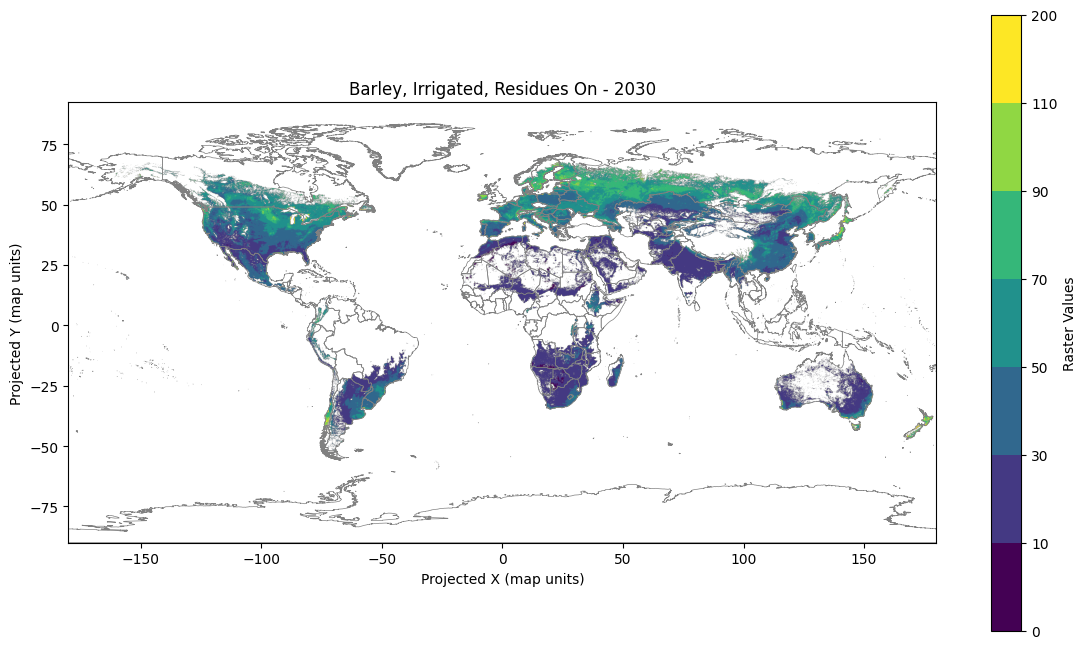

In [17]:
mp.plot_raster_on_world_extremes_cutoff(wheat_irr_ron, "Barley, Irrigated, Residues On - 2030", perc_cutoff=0, quantiles = q_breaks, raster_band = 15)

In [ ]:
wheat_rasters = [wheat_irr_roff, wheat_irr_ron, wheat_rf_roff, wheat_rf_ron]
wheat_titles=["Wheat, Irrigated, Residues Off", "Wheat, Irrigated, Residues On", "Wheat, Rainfed, Residues Off", "Wheat, Rainfed, Residues On"]

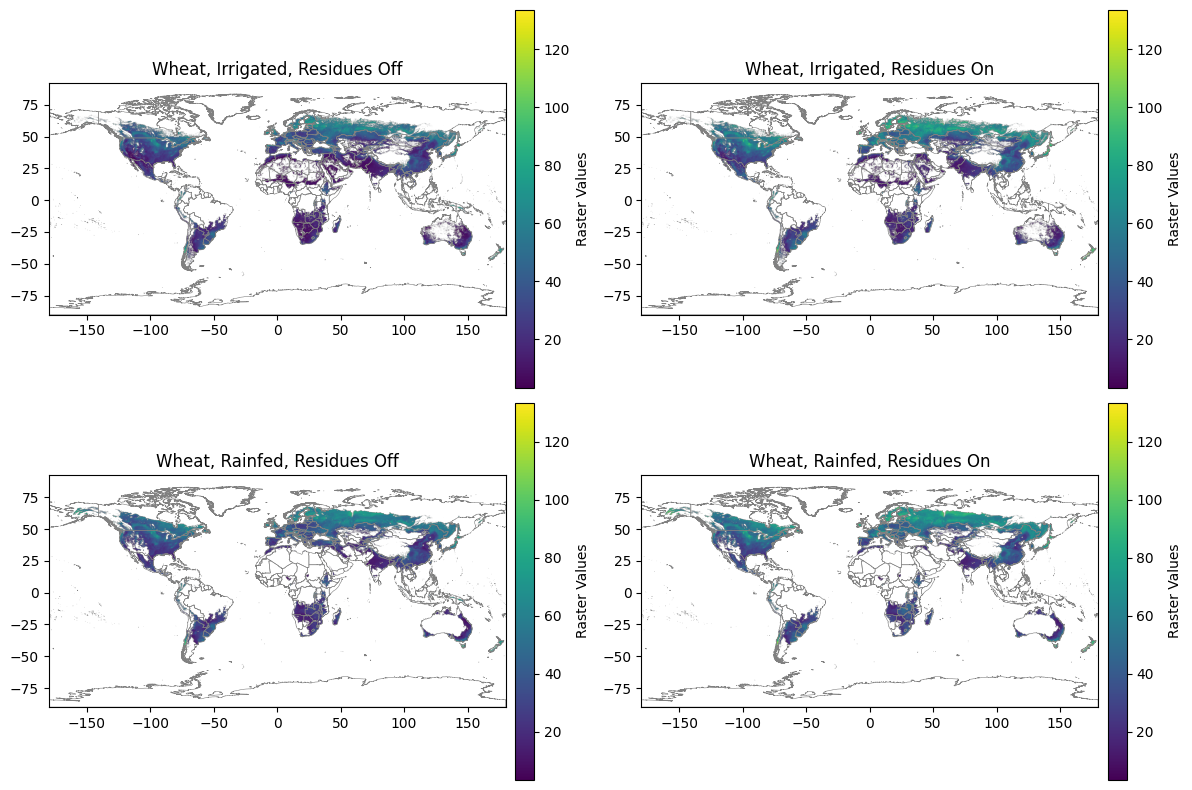

(<Figure size 1200x800 with 8 Axes>,
 array([[<Axes: title={'center': 'Wheat, Irrigated, Residues Off'}>,
         <Axes: title={'center': 'Wheat, Irrigated, Residues On'}>],
        [<Axes: title={'center': 'Wheat, Rainfed, Residues Off'}>,
         <Axes: title={'center': 'Wheat, Rainfed, Residues On'}>]],
       dtype=object))

In [ ]:
mp.plot_n_rasters_on_world_extremes_cutoff(wheat_rasters, 
                                           titles=wheat_titles,
                                           n_rows=2, n_cols=2, share_color_scale=True, raster_band=15, perc_cutoff=0)

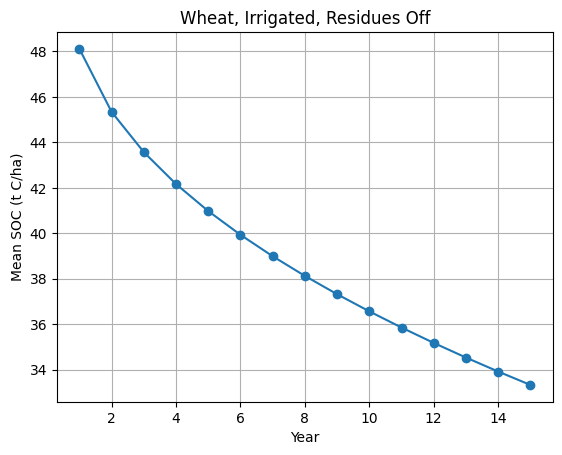

In [ ]:
mp.plot_multiband_raster_timesires(wheat_irr_roff, wheat_titles[0])

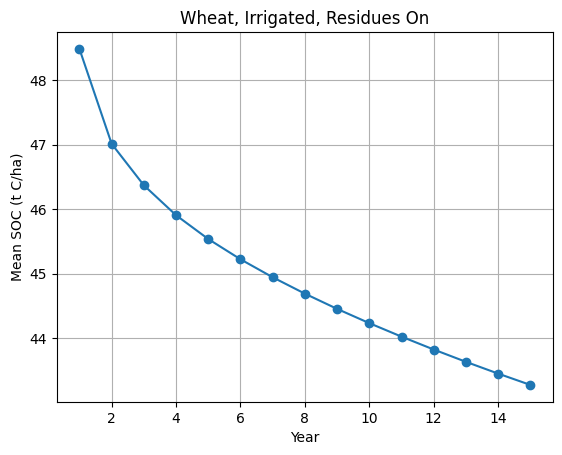

In [21]:
mp.plot_multiband_raster_timesires(wheat_irr_ron, wheat_titles[1])

#### Permanent crops

In [109]:
perm_crop_rothc_scenarios = "../data/crops/rothc_support/permcrops_baseline_rothc_scenarios_FAOGAEZ.xlsx"

In [112]:
rothc.run_rothc_crops_scenarios_from_excel(perm_crop_rothc_scenarios, all_new_files=False, run_test=False)

Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 26, falling back to string
Could not determine dtype for column 27, falling back to string


Running Permanent crop - Apple - irr
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Apple


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Apple_irr_2030y_SOC.tif
Permanent crop - Apple - irr calculated. Continuing...


Running Permanent crop - Banana - irr
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Banana


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

...

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Orange_rf_2030y_SOC.tif
Permanent crop - Orange - rf calculated. Continuing...


Running Permanent crop - Sugarcane - irr
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Sugarcane


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sugarcane_irr_2030y_SOC.tif
Permanent crop - Sugarcane - irr calculated. Continuing...


Running Permanent crop - Sugarcane - rf
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for permanent Sugarcane


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Sugarcane_rf_2030y_SOC.tif
Permanent crop - Sugarcane - rf calculated. Continuing...




Checking results...

In [113]:
soc_app_irr = soc_raster_folder/"Apple_irr_2030y_SOC.tif"
soc_ban_irr = soc_raster_folder/"Banana_irr_2030y_SOC.tif"

In [116]:
mp.inspect_raster(soc_app_irr)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Apple_irr_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC model results for year 2030 for Apple, irrigated
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 7.7331671714782715
  Max Value: 102.71637725830078
  Mean Value: 45.43032455444336
  Standard Deviation: 16.766597747802734

Band 2:
  Data Type: float32
  Min Value: 8.281105995178223
  Max Value: 102.71637725830078
  Mean Value: 42.55104446411133
  Standard Deviation: 16.528505325317383

Band 3:
  Data Type: float32


In [114]:
mp.inspect_raster(soc_ban_irr)

File: c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\Banana_irr_2030y_SOC.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 15
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
description: RothC model results for year 2030 for Banana, irrigated
long_name: Soil Organic Carbon
model: RothC rasterized vectorized
units: t C/ha
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 7.612054824829102
  Max Value: 137.71644592285156
  Mean Value: 39.15521240234375
  Standard Deviation: 16.119354248046875

Band 2:
  Data Type: float32
  Min Value: 7.291919708251953
  Max Value: 137.71644592285156
  Mean Value: 37.387855529785156
  Standard Deviation: 14.874855041503906

Band 3:
  Data Type: float3

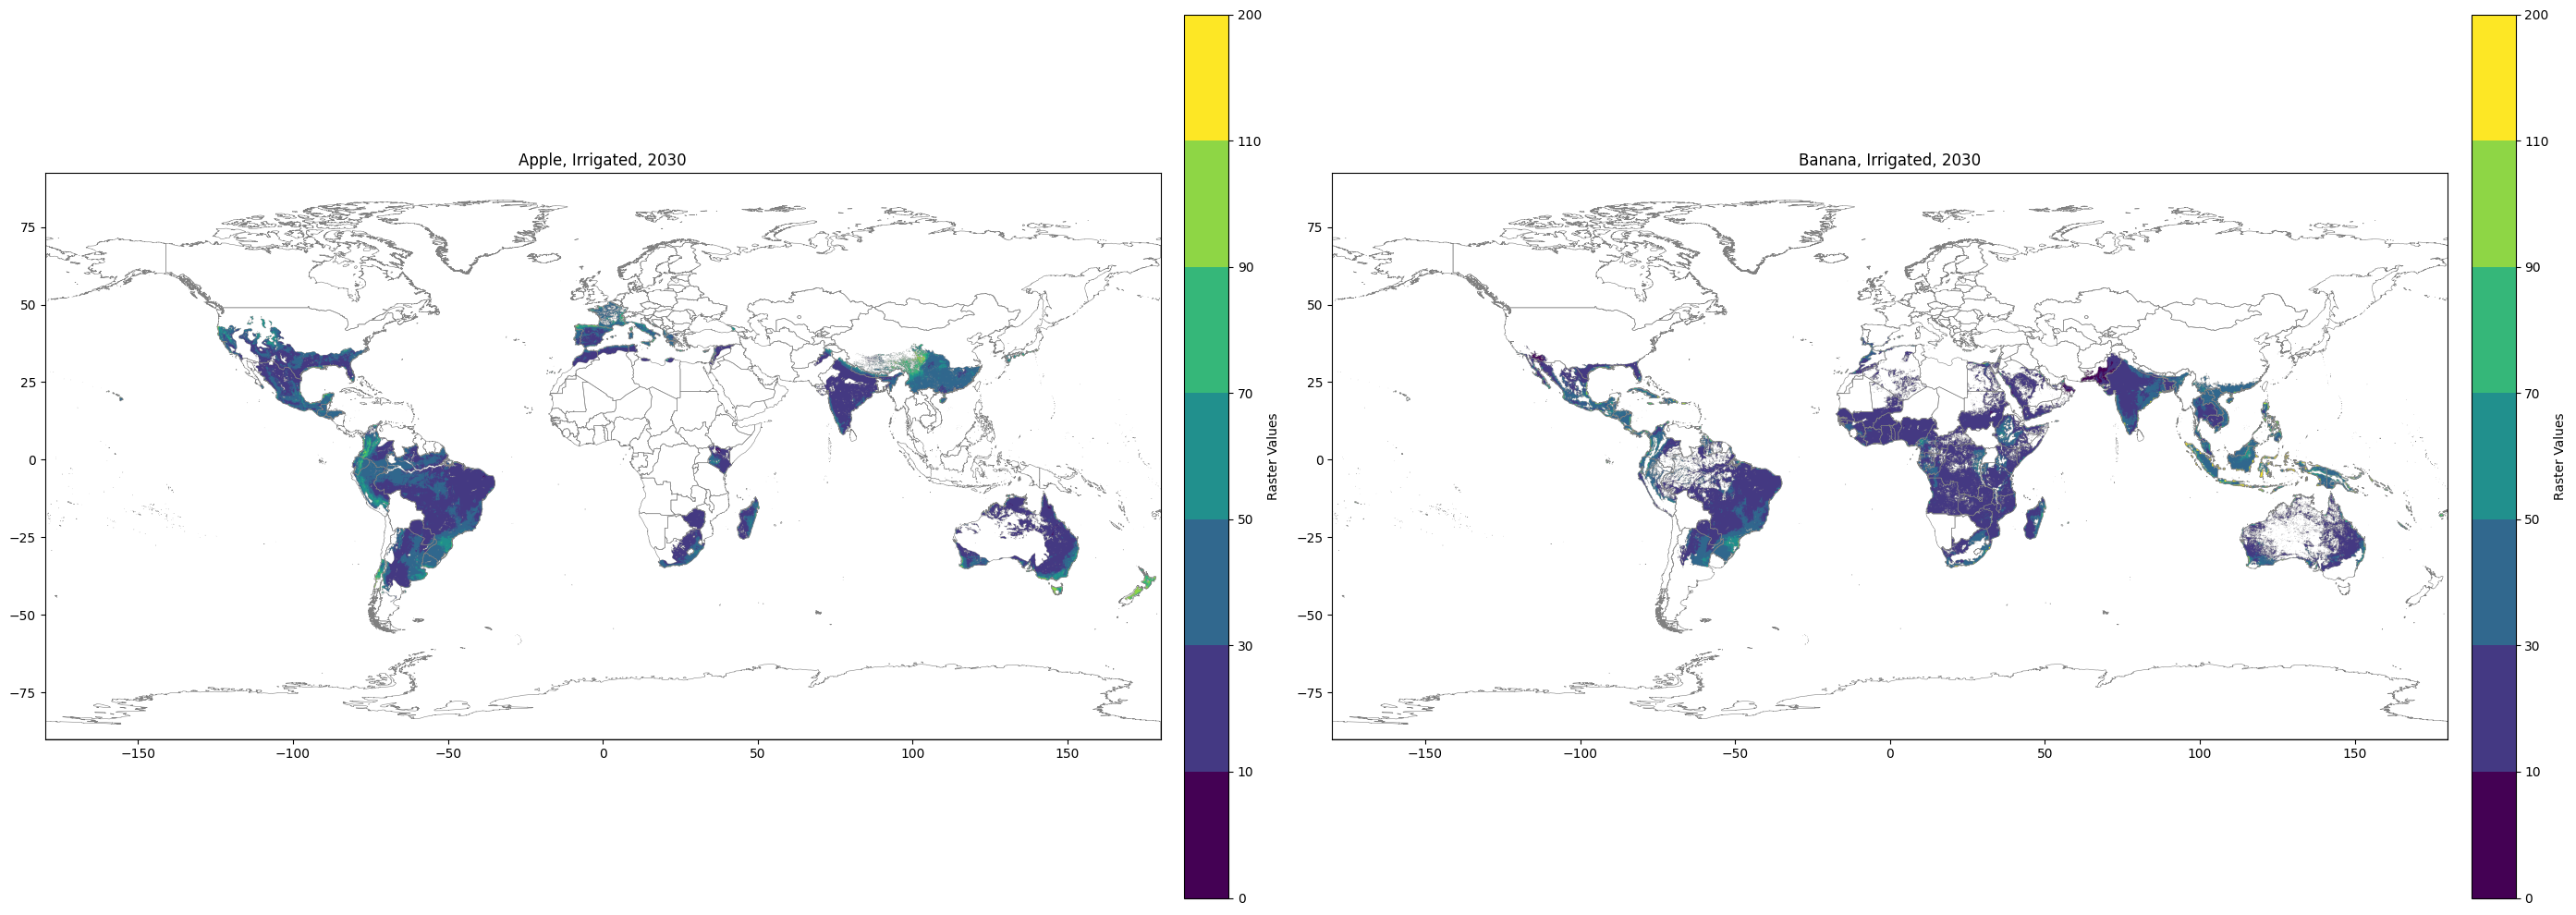

(<Figure size 2800x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Apple, Irrigated, 2030'}>,
         <Axes: title={'center': 'Banana, Irrigated, 2030'}>]],
       dtype=object))

In [121]:
mp.plot_n_rasters_on_world_extremes_cutoff([soc_app_irr, soc_ban_irr], 
                                           titles=["Apple, Irrigated, 2030", "Banana, Irrigated, 2030"],
                                           n_rows=1, n_cols=2, share_color_scale=True, raster_band=15, perc_cutoff=0, quantiles=q_breaks, x_size=14, y_size = 10)

## Regional Averages
Now that the new SOC values have been calculated, new regional averages need to be calculated. The filtering method has been updated to match the one just applied for yields.

### Countries

In [16]:
# Inputs that stay the same
input_folder = project_root / "LEAFs/SOC/rasters_clipped"
output_folder = project_root/"LEAFs/SOC/"
cf_name = "SOC_2030"
cf_unit = "t C/ha"
reset_gpck = True

In [17]:
# Inputs that change by area type
area_type = "country"
layer_name = "soc_leaf_country"
corrected_shp = gpd.read_file(project_root/'data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')
master_key = "ADM0_NAME"
result_key = "country"

In [99]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="SOC_2030_country_crops_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_NAME', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 15, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     
    reset_gpkg=reset_gpck,
    run_test=False,                             # Use run test to run the first 3 files
    max_workers=3
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-11 16:03:05,882 - INFO - Calculating SOC_2030 for Apple_irr_2030y_SOC...
Calculating SOC_2030 for Apple_irr_2030y_SOC...2026-05-11 16:03:05,886 - INFO - Calculating SOC_2030 for Apple_rf_2030y_SOC...

2026-05-11 16:03:05,890 - INFO - Calculating SOC_2030 for Banana_irr_2030y_SOC...
Calculating SOC_2030 for Apple_rf_2030y_SOC...


Processing rasters (soc_leaf_country):   0%|          | 0/63 [00:00<?, ?raster/s]

Calculating SOC_2030 for Banana_irr_2030y_SOC...
2026-05-11 16:04:47,071 - INFO - Calculating SOC_2030 for Banana_rf_2030y_SOC...
Calculating SOC_2030 for Banana_rf_2030y_SOC...
2026-05-11 16:06:07,442 - INFO - Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
2026-05-11 16:06:16,547 - INFO - Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
2026-05-11 16:07:00,942 - INFO - Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
2026-05-11 16:09:24,217 - INFO - Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
2026-05-11 16:09:33,932 - INFO - Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
2026-05-11 16:09:56,174 - INFO - Calculating SOC_2030 for Carrot_irr_2030y_SOC...
Calculating SOC_2030 for Carrot_irr_2030y_SOC...
20

Wrote 52164 rows into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCSOC_2030_country_crops_clipped.gpkg


In [18]:
gpck_countries = project_root/"LEAFs/SOCSOC_2030_country_crops_clipped.gpkg"

In [19]:
gdf_test_values = gpd.read_file(gpck_countries, layer=layer_name)
gdf_test_values.sort_values(by="cf", ascending=False).head(20)

,ADM0_NAME,flow_name,cf,cf_median,cf_std,_source_file
13611,French Polynesia,Sugarcane_irr_2030y_SOC,471.831238,470.776154,9.086628e+00,Sugarcane_irr_2030y_SOC.tif
13685,Mauritius,Sugarcane_irr_2030y_SOC,451.777283,463.484650,6.137782e+01,Sugarcane_irr_2030y_SOC.tif
13887,French Polynesia,Sugarcane_rf_2030y_SOC,399.983551,399.983551,5.684342e-14,Sugarcane_rf_2030y_SOC.tif
15759,Belgium,Tomato_irr_2030y_SOC,358.730865,386.698608,6.096317e+01,Tomato_irr_2030y_SOC.tif
15910,Netherlands,Tomato_irr_2030y_SOC,353.721466,378.025665,3.278024e+01,Tomato_irr_2030y_SOC.tif
15920,Norway,Tomato_irr_2030y_SOC,349.066101,386.698608,5.506868e+01,Tomato_irr_2030y_SOC.tif
15816,Finland,Tomato_irr_2030y_SOC,342.759735,386.698608,6.843929e+01,Tomato_irr_2030y_SOC.tif
15971,Sweden,Tomato_irr_2030y_SOC,340.551941,380.183502,6.567439e+01,Tomato_irr_2030y_SOC.tif
15801,Denmark,Tomato_irr_2030y_SOC,338.380066,368.213623,6.408111e+01,Tomato_irr_2030y_SOC.tif
13649,Jamaica,Sugarcane_irr_2030y_SOC,325.101410,307.706299,6.589546e+01,Sugarcane_irr_2030y_SOC.tif


In [20]:
gdf_test_geometries = gpd.read_file(gpck_countries, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM0_NAME")

In [21]:
test = gdf_test[gdf_test["flow_name"]=="Wheat_irr_ron_2030y_SOC"]
test

,ADM0_NAME,geometry,flow_name,cf,cf_median,cf_std
60,Abyei,"MULTIPOLYGON (((2795884.002 1224311.08, 279588...",Wheat_irr_ron_2030y_SOC,NaN,NaN,NaN
123,Afghanistan,"MULTIPOLYGON (((6850483.926 4556028.284, 68512...",Wheat_irr_ron_2030y_SOC,26.816006,25.996828,11.426821
186,Aksai Chin,"MULTIPOLYGON (((7617392.099 4026862.439, 76164...",Wheat_irr_ron_2030y_SOC,NaN,NaN,NaN
249,Albania,"MULTIPOLYGON (((1860613.351 4756904.449, 18611...",Wheat_irr_ron_2030y_SOC,56.157425,54.072212,9.937460
312,Algeria,"MULTIPOLYGON (((-184610.278 4207929.615, -1845...",Wheat_irr_ron_2030y_SOC,13.740534,11.351587,6.950881
...,...,...,...,...,...,...
17133,West Bank,"MULTIPOLYGON (((3389109.588 3849801.036, 33893...",Wheat_irr_ron_2030y_SOC,38.559731,29.953150,19.448404
17196,Western Sahara,"MULTIPOLYGON (((-1641480.465 2668968.614, -164...",Wheat_irr_ron_2030y_SOC,10.906327,10.457610,2.075197
17259,Yemen,"MULTIPOLYGON (((4067066.11 1896700.132, 406743...",Wheat_irr_ron_2030y_SOC,14.174150,13.157175,3.861978
17322,Zambia,"MULTIPOLYGON (((2970700.645 -1050157.82, 29715...",Wheat_irr_ron_2030y_SOC,28.010342,28.249804,3.534019


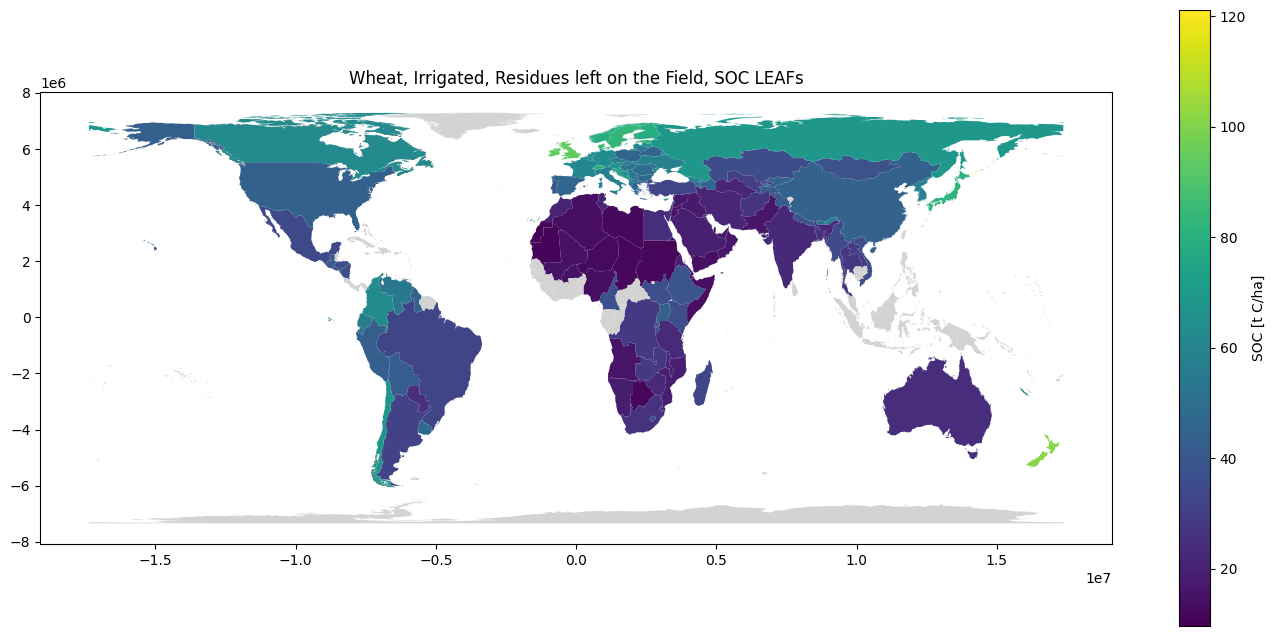

In [22]:
fig, ax = plt.subplots(figsize=(14, 8)) 
test.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Wheat, Irrigated, Residues left on the Field, SOC LEAFs")
plt.tight_layout() 
plt.show()

### Subcountries

In [24]:
# Inputs that change by area type
area_type = "subcountry"
layer_name = "soc_leaf_subcountry"
corrected_shp = gpd.read_file(project_root/'data/CountryLayers/SubCountry_Level1/g2015_2014_1.shp')
master_key = "ADM1_CODE"
result_key = "ADM1_CODE"

Running the averages

In [25]:
gpkg_path_sc, df_results_sc = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="SOC_2030_subcountry_crops_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_CODE', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    input_raster_key_startswith=None,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 15, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     # Chooses the raster band. Due to outliers in crops, setting it to windsorize, replacing all values outside 1, 99 percentiles with those values.
    reset_gpkg=True,
    run_test=False,
    max_workers=4
)

print(f"Wrote {df_results_sc.shape[0]} rows into {gpkg_path_sc}")

2026-05-11 19:02:43,746 - INFO - Building 'soc_leaf_subcountry' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC (c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCSOC_2030_subcountry_crops_clipped.gpkg)



Processing rasters (soc_leaf_subcountry):   0%|          | 0/63 [00:00<?, ?raster/s]

2026-05-11 19:03:08,477 - INFO - Calculating SOC_2030 for Apple_irr_2030y_SOC...
Calculating SOC_2030 for Apple_irr_2030y_SOC...
2026-05-11 19:03:08,492 - INFO - Calculating SOC_2030 for Apple_rf_2030y_SOC...
2026-05-11 19:03:08,495 - INFO - Calculating SOC_2030 for Banana_irr_2030y_SOC...
Calculating SOC_2030 for Apple_rf_2030y_SOC...
2026-05-11 19:03:08,497 - INFO - Calculating SOC_2030 for Banana_rf_2030y_SOC...
Calculating SOC_2030 for Banana_irr_2030y_SOC...


Processing rasters (soc_leaf_subcountry):   0%|          | 0/63 [00:00<?, ?raster/s]

Calculating SOC_2030 for Banana_rf_2030y_SOC...
2026-05-11 19:04:48,706 - INFO - Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
2026-05-11 19:04:54,412 - INFO - Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
2026-05-11 19:05:31,661 - INFO - Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
2026-05-11 19:05:49,380 - INFO - Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
2026-05-11 19:09:01,597 - INFO - Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
2026-05-11 19:09:48,784 - INFO - Calculating SOC_2030 for Carrot_irr_2030y_SOC...
Calculating SOC_2030 for Carrot_irr_2030y_SOC...
2026-05-11 19:10:13,497 - INFO - Calculating SOC_2030 for Cocoa_irr_2030y_SOC...
Calculating SOC_2030 for Cocoa_irr_2030y_SOC...
202

Wrote 646758 rows into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCSOC_2030_subcountry_crops_clipped.gpkg


Checking results...

In [26]:
gdf_test_values = gpd.read_file(gpkg_path_sc, layer=layer_name)
gdf_test_values.sort_values(by=["cf"], ascending=False).head(10)

,ADM1_CODE,flow_name,cf,cf_median,cf_std,_source_file
169672,2960,Sugarcane_irr_2030y_SOC,508.191895,508.191895,0.000000e+00,Sugarcane_irr_2030y_SOC.tif
167776,2025,Sugarcane_irr_2030y_SOC,508.191895,508.191895,5.684342e-14,Sugarcane_irr_2030y_SOC.tif
168495,2636,Sugarcane_irr_2030y_SOC,508.191895,508.191895,0.000000e+00,Sugarcane_irr_2030y_SOC.tif
169079,1143,Sugarcane_irr_2030y_SOC,501.918671,502.659454,5.326912e+00,Sugarcane_irr_2030y_SOC.tif
167773,2022,Sugarcane_irr_2030y_SOC,493.321411,508.191895,3.150327e+01,Sugarcane_irr_2030y_SOC.tif
167775,2024,Sugarcane_irr_2030y_SOC,481.367554,463.484650,2.190199e+01,Sugarcane_irr_2030y_SOC.tif
167770,2019,Sugarcane_irr_2030y_SOC,476.319855,488.433228,3.130587e+01,Sugarcane_irr_2030y_SOC.tif
171095,1273,Sugarcane_irr_2030y_SOC,471.831238,470.776154,9.086628e+00,Sugarcane_irr_2030y_SOC.tif
168574,1646,Sugarcane_irr_2030y_SOC,465.204895,508.191895,7.553304e+01,Sugarcane_irr_2030y_SOC.tif
168801,2188,Sugarcane_irr_2030y_SOC,462.730225,460.949219,4.180270e+01,Sugarcane_irr_2030y_SOC.tif


And it can be seen that the output has all values. Opening the dataset it can be seen it include NaNs.

To plot it, the geoemtries layer need to be imported as:

In [27]:
gdf_test_geometries = gpd.read_file(gpkg_path_sc, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM1_CODE")


Plotting Apples

In [28]:
Wheat_irr_ron = gdf_test[gdf_test["flow_name"]=="Wheat_irr_ron_2030y_SOC"]
Tomato_irr = gdf_test[gdf_test["flow_name"]=="Tomato_irr_2030y_SOC"]

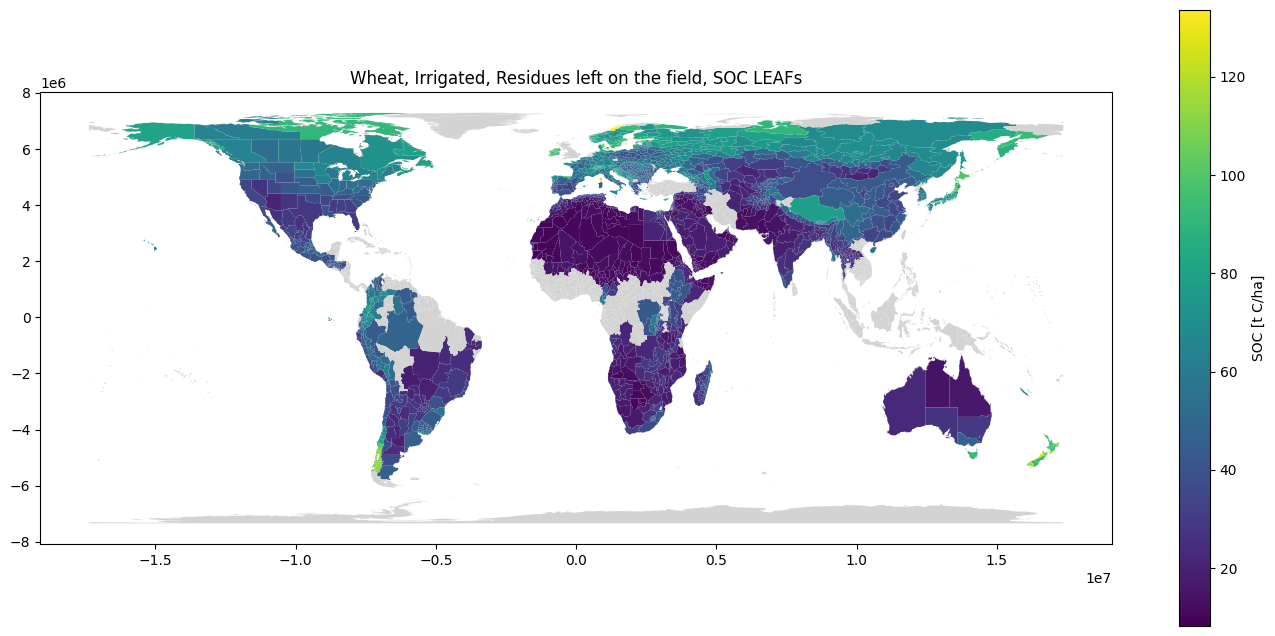

In [29]:
fig, ax = plt.subplots(figsize=(14, 8)) 
Wheat_irr_ron.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Wheat, Irrigated, Residues left on the field, SOC LEAFs")
plt.tight_layout() 
plt.show()

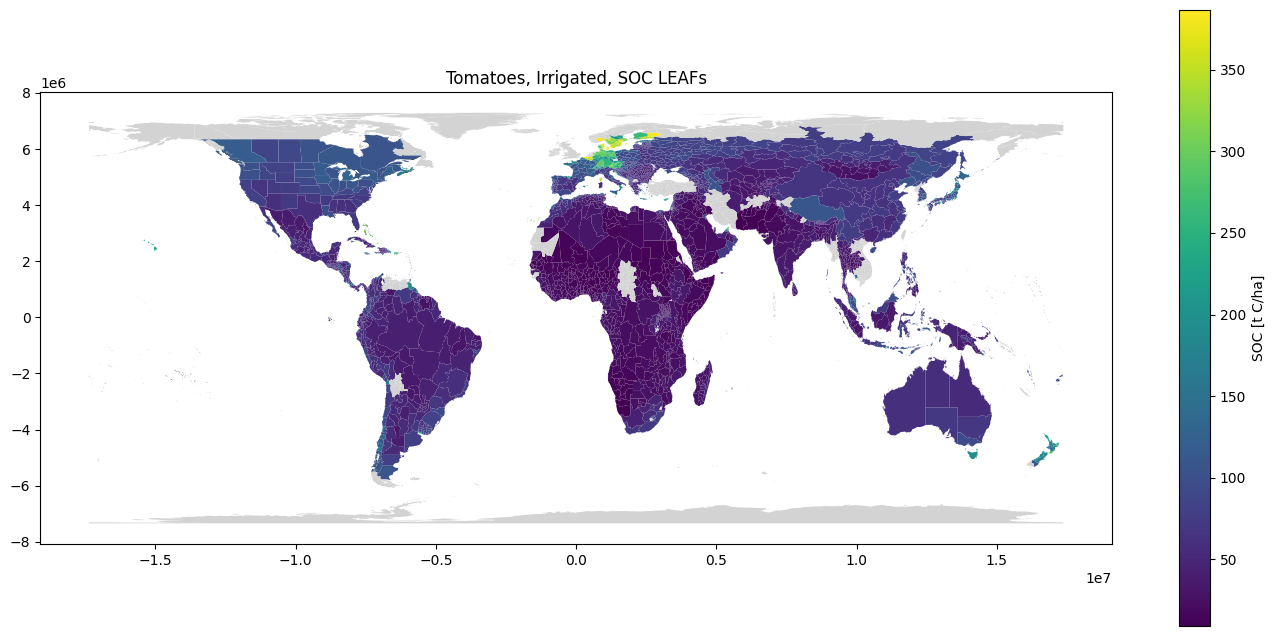

In [30]:
fig, ax = plt.subplots(figsize=(14, 8)) 
Tomato_irr.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Tomatoes, Irrigated, SOC LEAFs")
plt.tight_layout() 
plt.show()

### Ecoregions

In [31]:
# Inputs that change by area type
area_type = "ecoregion"
layer_name = "soc_leaf_ecoregions"
master_key = "ECO_ID"
result_key = "er_id"
er_gdf = gpd.read_file(project_root/"data/Ecoregions2017/Ecoregions2017.shp")

In [32]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="SOC_2030_ecoregions_crops_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=er_gdf,                  # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_CODE', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 15, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     # Chooses the raster band. Due to outliers in crops, setting it to windsorize, replacing all values outside 1, 99 percentiles with those values.
    reset_gpkg=True,
    run_test=False, 
    max_workers=4     
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-11 20:08:51,343 - INFO - Building 'soc_leaf_ecoregions' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC (c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCSOC_2030_ecoregions_crops_clipped.gpkg)



Processing rasters (soc_leaf_ecoregions):   0%|          | 0/63 [00:00<?, ?raster/s]

2026-05-11 20:09:11,422 - INFO - Calculating SOC_2030 for Apple_irr_2030y_SOC...
Calculating SOC_2030 for Apple_irr_2030y_SOC...2026-05-11 20:09:11,427 - INFO - Calculating SOC_2030 for Apple_rf_2030y_SOC...

Calculating SOC_2030 for Apple_rf_2030y_SOC...
2026-05-11 20:09:11,429 - INFO - Calculating SOC_2030 for Banana_irr_2030y_SOC...


Processing rasters (soc_leaf_ecoregions):   0%|          | 0/63 [00:00<?, ?raster/s]

Calculating SOC_2030 for Banana_irr_2030y_SOC...2026-05-11 20:09:11,434 - INFO - Calculating SOC_2030 for Banana_rf_2030y_SOC...

Calculating SOC_2030 for Banana_rf_2030y_SOC...
2026-05-11 20:15:38,657 - INFO - Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_2030y_SOC...
2026-05-11 20:15:43,341 - INFO - Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_2030y_SOC...
2026-05-11 20:15:50,176 - INFO - Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
Calculating SOC_2030 for Barley_rf_roff_2030y_SOC...
2026-05-11 20:16:11,467 - INFO - Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
Calculating SOC_2030 for Barley_rf_ron_2030y_SOC...
2026-05-11 20:23:20,224 - INFO - Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
Calculating SOC_2030 for Cabbage_irr_2030y_SOC...
2026-05-11 20:23:26,049 - INFO - Calculating SOC_2030 for Carrot_irr_2030y_SOC...
Calculating SOC_2030 for Carrot_irr_2030y_SOC...
20

Wrote 160083 rows into c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOCSOC_2030_ecoregions_crops_clipped.gpkg


In [12]:
gdf_test_values = gpd.read_file(gpkg_path, layer=layer_name)
gdf_test_values.sort_values(by=["cf"], ascending=False).head()

,ECO_ID,flow_name,cf,cf_median,cf_std,_source_file
41773,601,Sugarcane_irr_2030y_SOC,501.839020,502.659454,5.359022,Sugarcane_irr_2030y_SOC.tif
42136,630,Sugarcane_irr_2030y_SOC,473.193237,474.854156,9.049006,Sugarcane_irr_2030y_SOC.tif
41922,625,Sugarcane_irr_2030y_SOC,466.785858,470.776154,6.018748,Sugarcane_irr_2030y_SOC.tif
41924,20,Sugarcane_irr_2030y_SOC,452.676270,463.484650,65.944611,Sugarcane_irr_2030y_SOC.tif
42124,556,Sugarcane_irr_2030y_SOC,438.075104,447.483246,28.977474,Sugarcane_irr_2030y_SOC.tif


In [13]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ECO_ID")

In [14]:
Apples_irr = gdf_test[gdf_test["flow_name"]=="Apple_irr_2030y_SOC"]

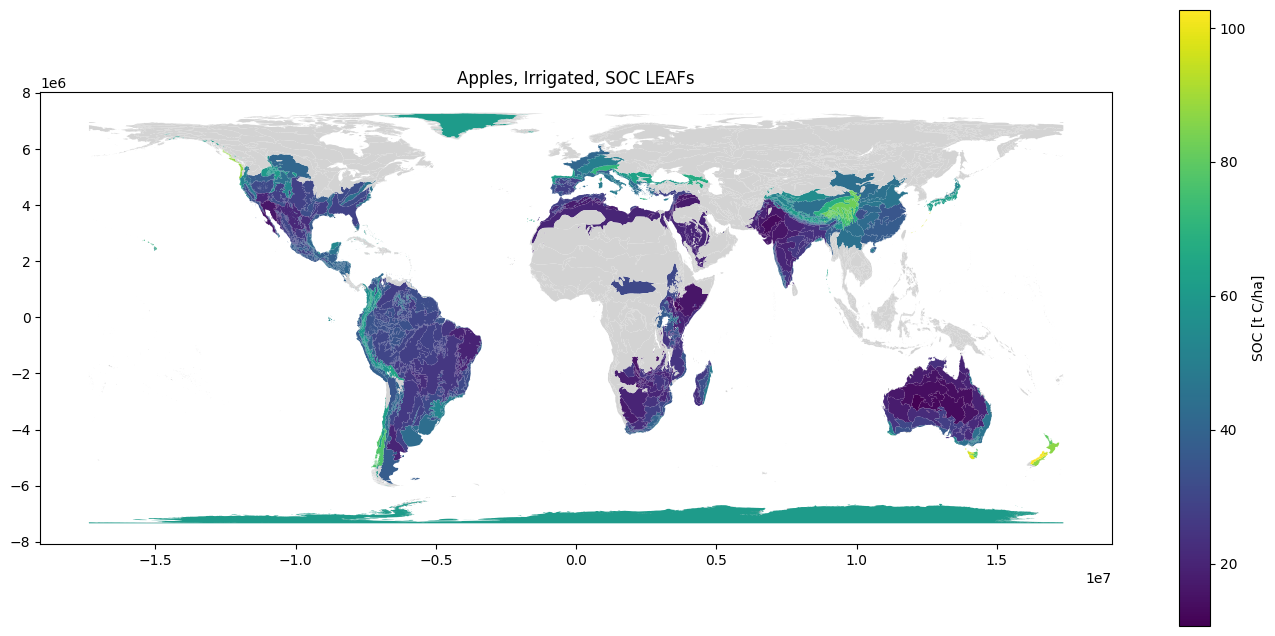

In [15]:
fig, ax = plt.subplots(figsize=(14, 8)) 
Apples_irr.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Apples, Irrigated, SOC LEAFs")
plt.tight_layout() 
plt.show()